In [9]:
# load packages
suppressWarnings(library(tidyverse, warn.conflicts = FALSE))
suppressWarnings(library(corrr, warn.conflicts = FALSE))
suppressWarnings(library(ggplot2, warn.conflicts = FALSE))
suppressWarnings(library(corrplot, warn.conflicts = FALSE))

In [10]:
# read the data
#raw_cts <- read_csv("./data/counts_raw.csv")
trans_cts <- read_tsv("./data/counts.tsv", col_types=cols())

In [11]:
data = trans_cts[, -which(tolower(names(trans_cts)) == "hugo_symbol" | tolower(names(trans_cts)) == "entrez_gene_id" | tolower(names(trans_cts)) == "symbol" | tolower(names(trans_cts)) == "gene")]

In [28]:
corrplot2 <- function(data,
                      method = "spearman",
                      sig.level = 0.05,
                      order = "original",
                      diag = FALSE,
                      type = "upper",
                      tl.srt = 90,
                      number.font = 1.0,
                      number.cex = 0.65,
                      mar = c(0, 0, 0, 0)) {
    data_incomplete <- data
    data <- data[complete.cases(data), ]
    mat <- cor(data, method = method)
    cor.mtest <- function(mat, method) {
        mat <- as.matrix(mat)
        n <- ncol(mat)
        p.mat <- matrix(NA, n, n)
        diag(p.mat) <- 0
        for (i in 1:(n - 1)) {
          for (j in (i + 1):n) {
            tmp <- cor.test(mat[, i], mat[, j], method = method, exact=FALSE)
            p.mat[i, j] <- p.mat[j, i] <- tmp$p.value
          }
        }
        colnames(p.mat) <- rownames(p.mat) <- colnames(mat)
        p.mat
    }
    p.mat <- cor.mtest(data, method = method)
    col <- colorRampPalette(c("#BB4444", "#EE9988", "#FFFFFF", "#77AADD", "#4477AA"))
    corrplot(mat,
        method = "color", col = col(200), number.font = number.font,
        mar = mar, number.cex = number.cex,
        type = type, order = order,
        addCoef.col = "black", # add correlation coefficient
        tl.col = "black", tl.srt = tl.srt, # rotation of text labels
        # combine with significance level
        p.mat = p.mat, sig.level = sig.level, insig = "blank",
        # hide correlation coefficients on the diagonal
        diag = diag,
        #shrink text labels
        tl.cex=0.65,
        col.lim=c(0,1)
    )
}


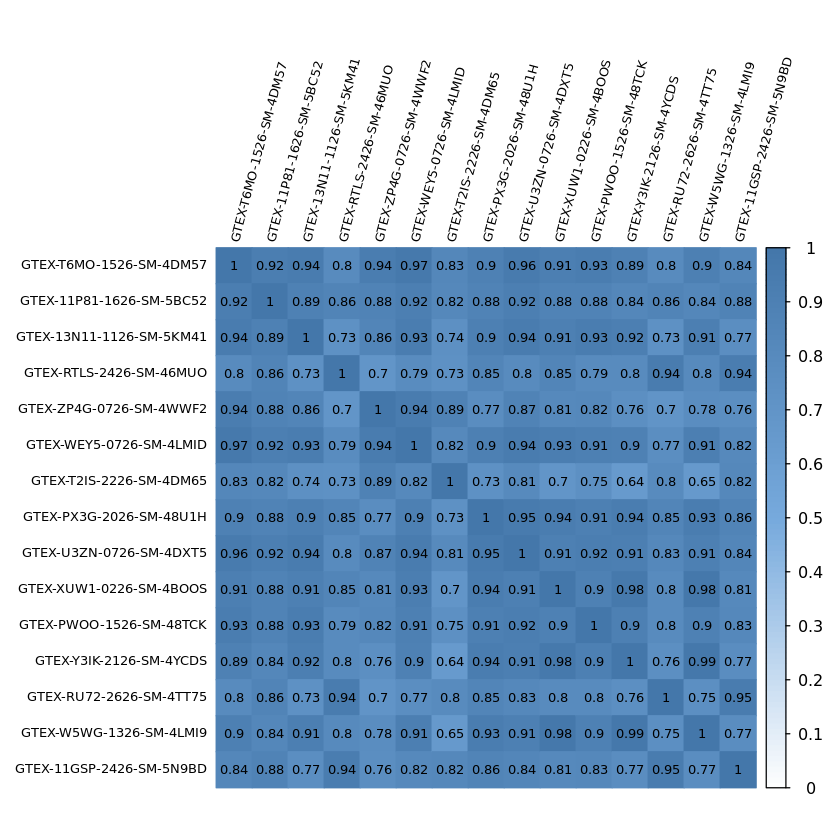

In [33]:
corrplot2(
  data = data,
  method = "pearson",
  sig.level = 0.5,
  order = "original",
  diag = TRUE,
  type = "full",
  tl.srt = 75
)


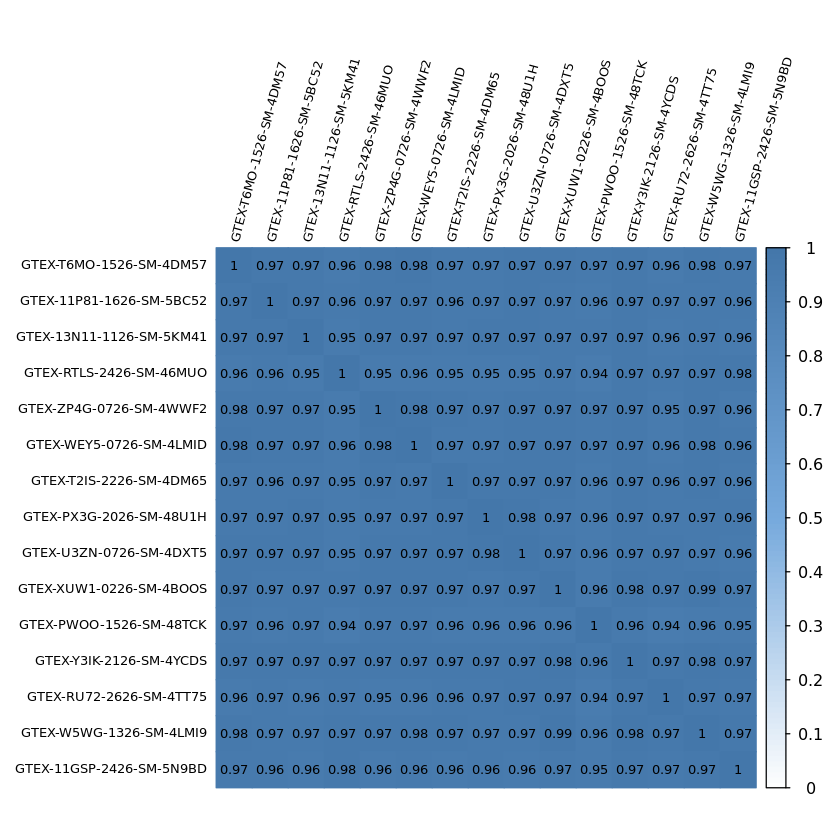

In [34]:
corrplot2(
  data = data,
  method = "spearman",
  sig.level = 0.5,
  order = "original",
  diag = TRUE,
  type = "full",
  tl.srt = 75
)
